In [2]:
import richfile as rfs
import numpy as np
# register numpy array type to richfile
rfs.functions.register_type(
    type_name="numpy_array",
    function_load=lambda path: np.load(path, allow_pickle=True),
    function_save=lambda path, obj: np.save(path, obj),
    object_class=np.ndarray,
    library="numpy",
    suffix="npy",
)


In [75]:
data_path = r'C:\Data\datasets\bmi_packets\bmi_packets'
r = rfs.RichFile(rf"{data_path}\mouse_0403R.richfile")  ## Path to an existing richfile
# Registering a new type for numpy arrays
r.register_type(
    type_name="numpy_array",
    function_load=lambda path: np.load(path, allow_pickle=True),
    function_save=lambda path, obj: np.save(path, obj),
    object_class=np.ndarray,
    library="numpy",
    suffix="npy",
)
# registering a new type for pandas dataframes
import pandas as pd
r.register_type(
    type_name="pandas_dataframe",
    function_load=lambda path: pd.read_csv(path),
    function_save=lambda path, obj: obj.to_csv(path, index=False),
    object_class=pd.DataFrame,
    library="pandas",
    suffix="csv",
)
# registering a new type for scipy
from scipy import sparse
r.register_type(
    type_name="scipy_sparse_matrix",
    function_load=lambda path: sparse.load_npz(path),
    function_save=lambda path, obj: sparse.save_npz(path, obj),
    object_class=sparse.spmatrix,
    library="scipy",
    suffix="npz",
)

r.view_directory_tree()

Viewing tree structure of richfile at path: C:\Data\datasets\bmi_packets\bmi_packets\mouse_0403R.richfile (dict)
├── data_neural_aligned.dict_item (dict_item)
|   ├── key.json (str)
|   ├── value.dict (dict)
|   |   ├── 20230702.dict_item (dict_item)
|   |   |   ├── key.json (str)
|   |   |   ├── value.npy (numpy_array)
|   |   |   
|   |   ├── 20230703.dict_item (dict_item)
|   |   |   ├── key.json (str)
|   |   |   ├── value.npy (numpy_array)
|   |   |   
|   |   ├── 20230706.dict_item (dict_item)
|   |   |   ├── key.json (str)
|   |   |   ├── value.npy (numpy_array)
|   |   |   
|   |   ├── 20230707.dict_item (dict_item)
|   |   |   ├── key.json (str)
|   |   |   ├── value.npy (numpy_array)
|   |   |   
|   |   ├── 20230708.dict_item (dict_item)
|   |   |   ├── key.json (str)
|   |   |   ├── value.npy (numpy_array)
|   |   |   
|   |   ├── 20230709.dict_item (dict_item)
|   |   |   ├── key.json (str)
|   |   |   ├── value.npy (numpy_array)
|   |   |   
|   |   
|   
├── weights_day0

<class 'numpy.ndarray'>
(589, 108000)


array([0.        , 0.11760958, 0.        , 0.        , 0.7962647 ,
       0.        , 0.3132821 , 0.19335885, 0.        , 0.17485702,
       0.        , 0.        , 0.04777494, 0.23745036, 0.        ,
       0.44963494, 0.10224701, 0.        , 0.        , 0.89411306,
       0.05712656, 0.        , 0.03834033, 0.6004244 , 0.42527914,
       0.34228945, 0.23107758, 0.9794743 , 0.06064115, 0.        ,
       0.        , 0.        , 1.2675003 , 0.08945724, 1.7341979 ,
       0.        , 0.5314336 , 0.00632514, 0.        , 0.22032976,
       0.        , 0.19896327, 0.        , 0.51501405, 0.        ,
       0.        , 0.9948934 , 0.9113166 , 0.3395715 , 0.05025537,
       0.14901203, 0.        , 0.        , 0.94044226, 0.        ,
       0.04907826, 0.        , 0.        , 0.        , 0.        ,
       0.3807057 , 0.6084623 , 0.        , 1.6340798 , 0.19317684,
       0.5367756 , 0.02132371, 0.        , 0.        , 0.        ,
       0.        , 0.06020384, 0.36760387, 0.1914356 , 0.     

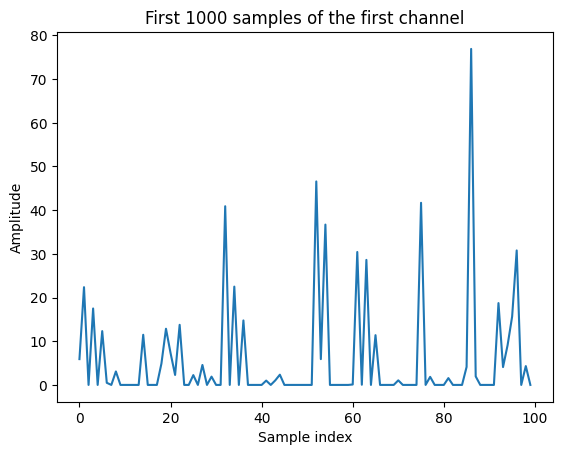

In [ ]:
data_oneday= r["data_neural_aligned"]["20230703"].load()
print(type(data_oneday))
print(data_oneday.shape)
# let plot the first 1000 samples of the first channel
import matplotlib.pyplot as plt
plt.plot(data_oneday[:100, 60])
plt.title("First 1000 samples of the first channel")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
# let print the first 10 values of the first channel
data_oneday[:100, 1]*(1/30)

c:\Users\alireza\miniconda3\envs\BCI_analysis\Lib\site-packages\richfile\util.py:295: UserWarning: Field 'versions_supported' is empty in type_lookup for type numpy_array.
  warnings.warn(f"Field 'versions_supported' is empty in type_lookup for type {metadata['type']}.")


shape: (589, 108000)
dtype: float32
min: 0.0
max: 582.728
mean: 2.6375346
std: 8.98138
fraction negative: 0.0
fraction exactly zero: 0.7005942432245488
fraction near zero: 0.7005942589448532
quantiles: [  0.           0.           0.           0.           0.
  13.91865635  39.28024719 107.14062529 582.72802734]


Text(0.5, 1.0, 'Histogram of channel means')

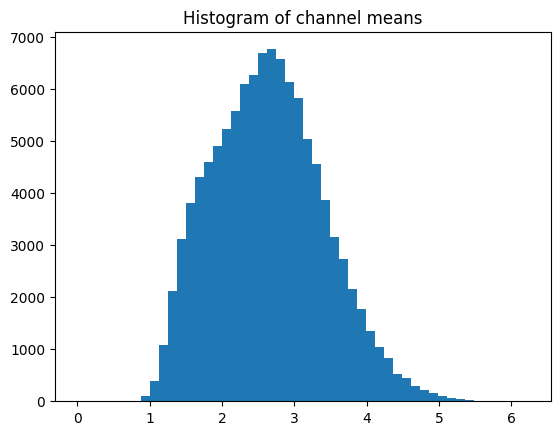

In [ ]:
x= r["data_neural_aligned"]["20230703"].load()
print("shape:", x.shape)
print("dtype:", x.dtype)
print("min:", np.nanmin(x))
print("max:", np.nanmax(x))
print("mean:", np.nanmean(x))
print("std:", np.nanstd(x))
print("fraction negative:", np.mean(x < 0))
print("fraction exactly zero:", np.mean(x == 0))
print("fraction near zero:", np.mean(np.abs(x) < 1e-6))
print("quantiles:", np.nanquantile(x, [0, 0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999, 1]))
# let print the histogram for the mean of each channel across time
channel_means = np.nanmean(x, axis=0)
plt.hist(channel_means, bins=50)
plt.title("Histogram of channel means")


In [100]:
exteras = r['extras']['logger_dfs'].load()
print(exteras.keys())

c:\Users\alireza\miniconda3\envs\BCI_analysis\Lib\site-packages\richfile\util.py:295: UserWarning: Field 'versions_supported' is empty in type_lookup for type pandas_dataframe.
  warnings.warn(f"Field 'versions_supported' is empty in type_lookup for type {metadata['type']}.")


dict_keys(['20230702', '20230703', '20230706', '20230707', '20230708', '20230709'])


In [96]:
# let make pandas dataframe from the extreras
exteras['20230703'].keys()

dict_keys(['decoder', 'motionCorrection', 'timeSeries', 'timers', 'trials'])

In [117]:
all_time_steps = exteras['20230706']['timers']['tic_toc']
# let plot the histogram of the time steps
print(f'time steps mean: {np.mean(all_time_steps):.3f} and std: {np.std(all_time_steps):.3f}, sample rate: {1/np.mean(all_time_steps):.2f} Hz')

time steps mean: 0.014 and std: 0.006, sample rate: 69.44 Hz


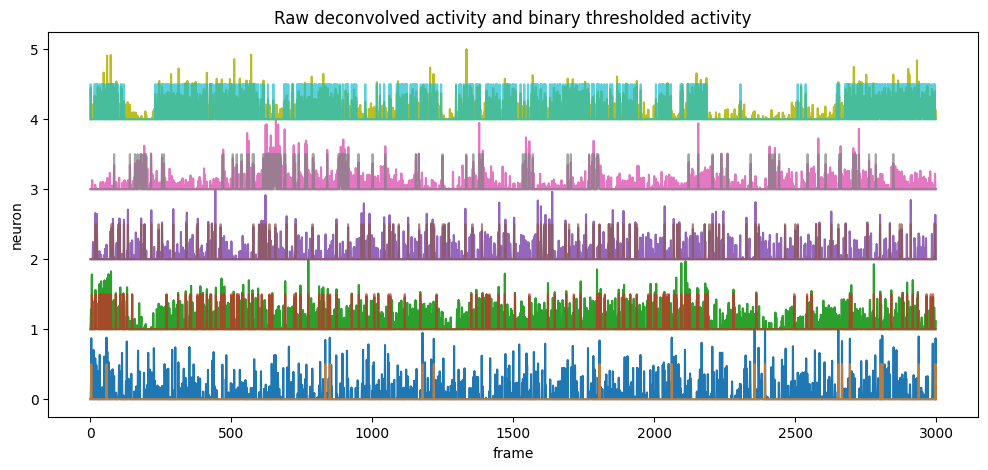

array([0.06014815, 0.06255556, 0.05742593, 0.04737963])

In [ ]:
x= r["data_neural_aligned"]["20230703"].load()
thresholds = np.percentile(x, 95, axis=1, keepdims=True)
x_binary = (x > thresholds).astype(np.uint8)

k =   # try 1, 2, or 3
mu = np.mean(x, axis=1, keepdims=True)
sigma = np.std(x, axis=1, keepdims=True)
thresholds = mu + k * sigma
x_binary = (x > thresholds).astype(np.uint8)

neurons = [0, 1, 2, 3, 4]
T = 3000

plt.figure(figsize=(12, 5))

for i, n in enumerate(neurons):
    plt.plot(x[n, :T] / np.nanmax(x[n, :T] + 1e-9) + i, label=f"neuron {n}")
    plt.plot(x_binary[n, :T] * 0.5 + i, alpha=0.7)

plt.xlabel("frame")
plt.ylabel("neuron")
plt.title("Raw deconvolved activity and binary thresholded activity")
plt.show()
# let calulate the sparcity of each channel
sparsity = np.mean(x_binary, axis=1)
sparsity[0:4]

In [140]:
matlab_save_path = r"C:\Users\alireza\Documents\Git\Minimal_computation"
from scipy.io import savemat
from pathlib import Path
import os
data_path = r'C:\Data\datasets\bmi_packets\bmi_packets'
r = rfs.RichFile(rf"{data_path}\mouse_0403R.richfile") 
x= r["data_neural_aligned"]["20230702"].load()
save_path = os.path.join(matlab_save_path, "mouse_0403R_20230702.mat")
savemat(save_path, {"x": x})
print(f"saved to: {save_path}")

saved to: C:\Users\alireza\Documents\Git\Minimal_computation\mouse_0403R_20230702.mat


In [5]:
np_save_path = r"C:\Users\alireza\Documents\Git\higher-order-feature-leakage\data"
data_path = r'C:\Data\datasets\bmi_packets\bmi_packets'
mouse_id = "mouse_0403R"
session_name = "20230702"
r = rfs.RichFile(rf"{data_path}\{mouse_id}.richfile") 
X=r["data_neural_aligned"][session_name].load()
np.save(rf"{np_save_path}\{mouse_id}_{session_name}_2p_spk.npy", X)


In [6]:
X.shape

(589, 108000)

In [168]:
bastjin_data_path = r'C:\Data\datasets\Bastijn\acdc\20260206\suite2p\plane0'
# load the nyp files in the directory
file_name = 'iscell'
# let load the nyp file
is_cell = np.load(os.path.join(bastjin_data_path, f"{file_name}.npy"), allow_pickle=True)

file_name = 'spks'
x_raw = np.load(os.path.join(bastjin_data_path, f"{file_name}.npy"), allow_pickle=True)

# let remove the non-cell from the data
x = x_raw[is_cell[:, 0].astype(bool), :]

shape: (701, 82803)
dtype: float32
min: 0.0
max: 76.92639
mean: 0.25261843
std: 0.96932775
fraction negative: 0.0
fraction exactly zero: 0.7254290182895129
fraction near zero: 0.7254295868148837
quantiles: [ 0.          0.          0.          0.          0.          1.2395421
  3.70877355 13.09231002 76.9263916 ]


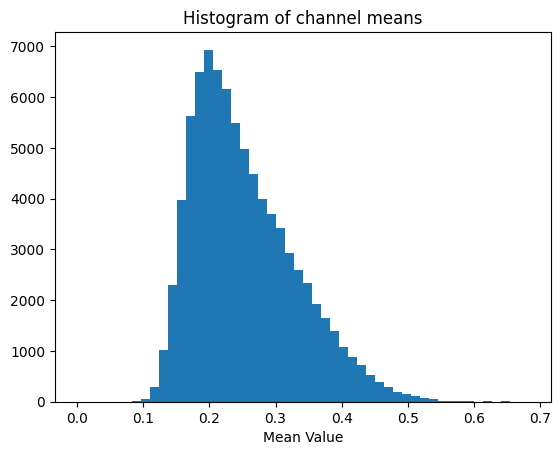

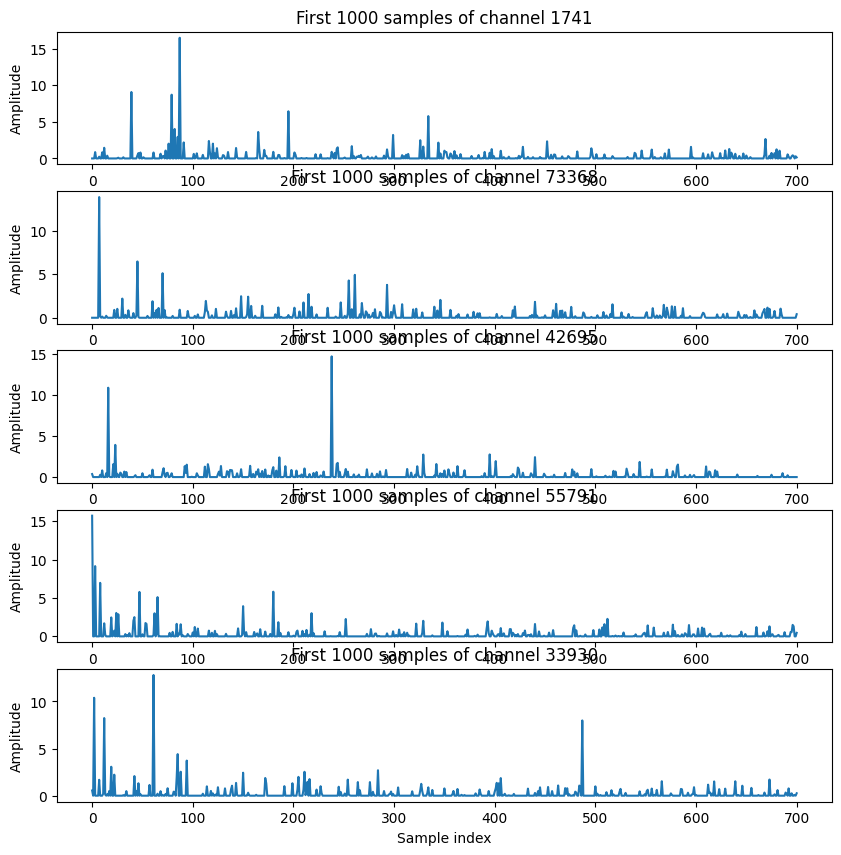

In [169]:
print("shape:", x.shape)
print("dtype:", x.dtype)
print("min:", np.nanmin(x))
print("max:", np.nanmax(x))
print("mean:", np.nanmean(x))
print("std:", np.nanstd(x))
print("fraction negative:", np.mean(x < 0))
print("fraction exactly zero:", np.mean(x == 0))
print("fraction near zero:", np.mean(np.abs(x) < 1e-6))
print("quantiles:", np.nanquantile(x, [0, 0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999, 1]))
# let print the histogram for the mean of each channel across time
channel_means = np.nanmean(x, axis=0)
plt.hist(channel_means, bins=50)
plt.title("Histogram of channel means")
plt.xlabel("Mean Value")
# let plot the first 1000 samples of 5 randomly selected channels
random_channels = np.random.randint(x.shape[1], size=5)
fig, ax = plt.subplots(5, 1, figsize=(10, 10))
for i, channel in enumerate(random_channels):
    ax[i].plot(x[:1000, channel])
    ax[i].set_title(f"First 1000 samples of channel {channel}")
    ax[i].set_xlabel("Sample index")
    ax[i].set_ylabel("Amplitude")

In [170]:
matlab_save_path = r"C:\Users\alireza\Documents\Git\Minimal_computation"
save_path = os.path.join(matlab_save_path, "bastjin_20260206_plane0.mat")
savemat(save_path, {"X": x})
print(f"saved to: {save_path}")

saved to: C:\Users\alireza\Documents\Git\Minimal_computation\bastjin_20260206_plane0.mat


In [ ]:
np_save_path = r"CC:\Users\alireza\Documents\Git\higher-order-feature-leakage\data"
np.save(os.path.join(np_save_path, "bastjin_20260206_plane0.npy"), x)